# **==========  User Analytics in the Telecommunication Industry  ==========**

# **Import Library**

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import pairwise_distances

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error
from IPython.display import HTML, display



# **Load The Dataset**

In [3]:
df = pd.read_csv('telcom_data.csv')

In [4]:
pd.set_option('display.max_columns', 100)

In [5]:
df.head()

,Bearer Id,Start,Start ms,End,End ms,Dur. (ms),IMSI,MSISDN/Number,IMEI,Last Location Name,Avg RTT DL (ms),Avg RTT UL (ms),Avg Bearer TP DL (kbps),Avg Bearer TP UL (kbps),TCP DL Retrans. Vol (Bytes),TCP UL Retrans. Vol (Bytes),DL TP < 50 Kbps (%),50 Kbps < DL TP < 250 Kbps (%),250 Kbps < DL TP < 1 Mbps (%),DL TP > 1 Mbps (%),UL TP < 10 Kbps (%),10 Kbps < UL TP < 50 Kbps (%),50 Kbps < UL TP < 300 Kbps (%),UL TP > 300 Kbps (%),HTTP DL (Bytes),HTTP UL (Bytes),Activity Duration DL (ms),Activity Duration UL (ms),Dur. (ms).1,Handset Manufacturer,Handset Type,Nb of sec with 125000B < Vol DL,Nb of sec with 1250B < Vol UL < 6250B,Nb of sec with 31250B < Vol DL < 125000B,Nb of sec with 37500B < Vol UL,Nb of sec with 6250B < Vol DL < 31250B,Nb of sec with 6250B < Vol UL < 37500B,Nb of sec with Vol DL < 6250B,Nb of sec with Vol UL < 1250B,Social Media DL (Bytes),Social Media UL (Bytes),Google DL (Bytes),Google UL (Bytes),Email DL (Bytes),Email UL (Bytes),Youtube DL (Bytes),Youtube UL (Bytes),Netflix DL (Bytes),Netflix UL (Bytes),Gaming DL (Bytes),Gaming UL (Bytes),Other DL (Bytes),Other UL (Bytes),Total UL (Bytes),Total DL (Bytes)
0,1.311450e+19,4/4/19 12:01,770.0,4/25/19 14:35,662.0,1823652.0,2.082014e+14,3.366496e+10,3.552121e+13,9.16457E+15,42.0,5.0,23.0,44.0,NaN,NaN,100.0,0.0,0.0,0.0,100.0,0.0,0.0,0.0,NaN,NaN,37624.0,38787.0,1.823653e+09,Samsung,Samsung Galaxy A5 Sm-A520F,NaN,NaN,NaN,NaN,NaN,NaN,213.0,214.0,1545765.0,24420.0,1634479.0,1271433.0,3563542.0,137762.0,15854611.0,2501332.0,8198936.0,9656251.0,278082303.0,14344150.0,171744450.0,8814393.0,36749741.0,308879636.0
1,1.311450e+19,4/9/19 13:04,235.0,4/25/19 8:15,606.0,1365104.0,2.082019e+14,3.368185e+10,3.579401e+13,L77566A,65.0,5.0,16.0,26.0,NaN,NaN,100.0,0.0,0.0,0.0,100.0,0.0,0.0,0.0,NaN,NaN,168.0,3560.0,1.365104e+09,Samsung,Samsung Galaxy J5 (Sm-J530),NaN,NaN,NaN,NaN,NaN,NaN,971.0,1022.0,1926113.0,7165.0,3493924.0,920172.0,629046.0,308339.0,20247395.0,19111729.0,18338413.0,17227132.0,608750074.0,1170709.0,526904238.0,15055145.0,53800391.0,653384965.0
2,1.311450e+19,4/9/19 17:42,1.0,4/25/19 11:58,652.0,1361762.0,2.082003e+14,3.376063e+10,3.528151e+13,D42335A,NaN,NaN,6.0,9.0,NaN,NaN,100.0,0.0,0.0,0.0,100.0,0.0,0.0,0.0,NaN,NaN,0.0,0.0,1.361763e+09,Samsung,Samsung Galaxy A8 (2018),NaN,NaN,NaN,NaN,NaN,NaN,751.0,695.0,1684053.0,42224.0,8535055.0,1694064.0,2690151.0,672973.0,19725661.0,14699576.0,17587794.0,6163408.0,229584621.0,395630.0,410692588.0,4215763.0,27883638.0,279807335.0
3,1.311450e+19,4/10/19 0:31,486.0,4/25/19 7:36,171.0,1321509.0,2.082014e+14,3.375034e+10,3.535661e+13,T21824A,NaN,NaN,44.0,44.0,NaN,NaN,100.0,0.0,0.0,0.0,100.0,0.0,0.0,0.0,NaN,NaN,3330.0,37882.0,1.321510e+09,undefined,undefined,NaN,NaN,NaN,NaN,NaN,NaN,17.0,207.0,644121.0,13372.0,9023734.0,2788027.0,1439754.0,631229.0,21388122.0,15146643.0,13994646.0,1097942.0,799538153.0,10849722.0,749039933.0,12797283.0,43324218.0,846028530.0
4,1.311450e+19,4/12/19 20:10,565.0,4/25/19 10:40,954.0,1089009.0,2.082014e+14,3.369980e+10,3.540701e+13,D88865A,NaN,NaN,6.0,9.0,NaN,NaN,100.0,0.0,0.0,0.0,100.0,0.0,0.0,0.0,NaN,NaN,0.0,0.0,1.089009e+09,Samsung,Samsung Sm-G390F,NaN,NaN,NaN,NaN,NaN,NaN,607.0,604.0,862600.0,50188.0,6248284.0,1500559.0,1936496.0,173853.0,15259380.0,18962873.0,17124581.0,415218.0,527707248.0,3529801.0,550709500.0,13910322.0,38542814.0,569138589.0


In [6]:
df.tail()

,Bearer Id,Start,Start ms,End,End ms,Dur. (ms),IMSI,MSISDN/Number,IMEI,Last Location Name,Avg RTT DL (ms),Avg RTT UL (ms),Avg Bearer TP DL (kbps),Avg Bearer TP UL (kbps),TCP DL Retrans. Vol (Bytes),TCP UL Retrans. Vol (Bytes),DL TP < 50 Kbps (%),50 Kbps < DL TP < 250 Kbps (%),250 Kbps < DL TP < 1 Mbps (%),DL TP > 1 Mbps (%),UL TP < 10 Kbps (%),10 Kbps < UL TP < 50 Kbps (%),50 Kbps < UL TP < 300 Kbps (%),UL TP > 300 Kbps (%),HTTP DL (Bytes),HTTP UL (Bytes),Activity Duration DL (ms),Activity Duration UL (ms),Dur. (ms).1,Handset Manufacturer,Handset Type,Nb of sec with 125000B < Vol DL,Nb of sec with 1250B < Vol UL < 6250B,Nb of sec with 31250B < Vol DL < 125000B,Nb of sec with 37500B < Vol UL,Nb of sec with 6250B < Vol DL < 31250B,Nb of sec with 6250B < Vol UL < 37500B,Nb of sec with Vol DL < 6250B,Nb of sec with Vol UL < 1250B,Social Media DL (Bytes),Social Media UL (Bytes),Google DL (Bytes),Google UL (Bytes),Email DL (Bytes),Email UL (Bytes),Youtube DL (Bytes),Youtube UL (Bytes),Netflix DL (Bytes),Netflix UL (Bytes),Gaming DL (Bytes),Gaming UL (Bytes),Other DL (Bytes),Other UL (Bytes),Total UL (Bytes),Total DL (Bytes)
149996,7.277830e+18,4/29/19 7:28,451.0,4/30/19 6:02,214.0,81230.0,2.082022e+14,3.365069e+10,3.548311e+13,D20434A,32.0,0.0,52.0,65.0,NaN,NaN,100.0,0.0,0.0,0.0,100.0,0.0,0.0,0.0,NaN,NaN,42376.0,41915.0,81230763.0,Apple,Apple iPhone 8 Plus (A1897),NaN,NaN,NaN,NaN,NaN,NaN,223.0,229.0,3464974.000,52091.00000,9967603.000,2817311.000,57639.000,633237.0000,16191667.0,11763428.00,17883703.00,19678161.00,526609673.0,9.197207e+06,3264510.0,1.348742e+07,57628851.0,574175259.0
149997,7.349880e+18,4/29/19 7:28,483.0,4/30/19 10:41,187.0,97970.0,2.082019e+14,3.366345e+10,3.566051e+13,D10223C,27.0,2.0,23.0,54.0,NaN,NaN,100.0,0.0,0.0,0.0,100.0,0.0,0.0,0.0,NaN,NaN,17264.0,16759.0,97970704.0,Apple,Apple iPhone Se (A1723),NaN,NaN,NaN,NaN,NaN,NaN,105.0,102.0,2344568.000,7613.00000,2229420.000,2185941.000,1954414.000,167304.0000,13877234.0,8288284.00,19350146.00,21293148.00,626893062.0,4.735033e+06,712180387.0,2.457758e+06,39135081.0,666648844.0
149998,1.311450e+19,4/29/19 7:28,283.0,4/30/19 10:46,810.0,98249.0,2.082017e+14,3.362189e+10,3.572121e+13,T51102A,43.0,6.0,43.0,47.0,NaN,NaN,100.0,0.0,0.0,0.0,100.0,0.0,0.0,0.0,NaN,NaN,25003.0,28640.0,98249527.0,Apple,Apple iPhone Xs (A2097),NaN,NaN,NaN,NaN,NaN,NaN,104.0,108.0,1245845.000,14394.00000,3850890.000,2734579.000,1525734.000,532543.0000,22660510.0,1855903.00,9963942.00,5065760.00,553539484.0,1.339432e+07,121100856.0,1.131473e+07,34912224.0,592786405.0
149999,1.311450e+19,4/29/19 7:28,696.0,4/30/19 10:40,327.0,97910.0,2.082021e+14,3.361962e+10,8.618620e+13,L88342B,37.0,5.0,34.0,37.0,NaN,NaN,100.0,0.0,0.0,0.0,100.0,0.0,0.0,0.0,NaN,NaN,13405.0,34088.0,97910631.0,Huawei,Huawei Fig-Lx1,NaN,NaN,NaN,NaN,NaN,NaN,43.0,82.0,801547.000,21562.00000,4189773.000,3567494.000,2228270.000,622644.0000,8817106.0,8305402.00,3322253.00,13172589.00,352536971.0,2.529475e+06,814713113.0,1.406930e+06,29626096.0,371895920.0
150000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1795321.774,32928.43438,5750752.619,2056541.926,1791728.868,467373.4419,11634072.5,11009410.13,11626851.72,11001754.82,422044702.6,8.288398e+06,421100544.2,8.264799e+06,NaN,NaN


 * **We use pd.read_csv()** to load the dataset into a DataFrame. This step imports the raw data so we can analyze it.
 * **df.head()** shows the first 5 rows of the dataset. It helps us quickly check the structure, column names, and sample values.
 * **df.tail()** shows the last 5 rows of the dataset. It helps us confirm if the data is complete and check the ending records.

# **Data Cleaning**

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150001 entries, 0 to 150000
Data columns (total 55 columns):
 #   Column                                    Non-Null Count   Dtype  
---  ------                                    --------------   -----  
 0   Bearer Id                                 149010 non-null  float64
 1   Start                                     150000 non-null  object 
 2   Start ms                                  150000 non-null  float64
 3   End                                       150000 non-null  object 
 4   End ms                                    150000 non-null  float64
 5   Dur. (ms)                                 150000 non-null  float64
 6   IMSI                                      149431 non-null  float64
 7   MSISDN/Number                             148935 non-null  float64
 8   IMEI                                      149429 non-null  float64
 9   Last Location Name                        148848 non-null  object 
 10  Avg RTT DL (ms)     

* **df.info()** gives a concise summary of the dataset.

* It shows the number of rows, number of columns, column names, data types and how many non-null values each column has.

* This helps us quickly identify missing values and incorrect data types before cleaning.

# **Handling Datatypes and drop annecessary columns**

In [8]:
df['Start'] = pd.to_datetime(df['Start'], errors='coerce',format='mixed')
df['End'] = pd.to_datetime(df['End'],errors='coerce',format='mixed')

df = df.dropna(subset=['MSISDN/Number'])
df['Bearer Id'] = df['Bearer Id'].astype('str')
df['IMSI'] = df['IMSI'].astype('str')
df['MSISDN/Number'] = df['MSISDN/Number'].astype('int64').astype('str')
df['IMEI'] = df['IMEI'].astype('str')

unnecessary_cols =["DL TP < 50 Kbps (%)",
                   "50 Kbps < DL TP < 250 Kbps (%)",
                   "250 Kbps < DL TP < 1 Mbps (%)",
                   "DL TP > 1 Mbps (%)",
                   "UL TP < 10 Kbps (%)",
                   "10 Kbps < UL TP < 50 Kbps (%)",
                   "50 Kbps < UL TP < 300 Kbps (%)",
                   "UL TP > 300 Kbps (%)",
                   "Nb of sec with 125000B < Vol DL",
                   "Nb of sec with 1250B < Vol UL < 6250B",
                   "Nb of sec with 31250B < Vol DL < 125000B",
                   "Nb of sec with 37500B < Vol UL",
                   "Nb of sec with 6250B < Vol DL < 31250B",
                   "Nb of sec with 6250B < Vol UL < 37500B",
                   "Nb of sec with Vol DL < 6250B",
                   "Nb of sec with Vol UL < 1250B"]
df = df.drop(columns=[col for col in unnecessary_cols if col in df.columns])

* We convert **Start and End** columns into proper datetime format using pd.to_datetime().
* **Bearer Id,IMSI, MSISDN/Number, IMEI :** These are unique identifiers, not meant for mathematical calculations.
* Converting them to string preserves integrity.
* This makes them safe for joins, grouping, and merging.
* Drop unnecessary column

# **Missing Value Detection**

In [9]:
missing_values = df.isnull().sum()
missing_values

,0
Bearer Id,0
Start,0
Start ms,0
End,0
End ms,0
Dur. (ms),0
IMSI,0
MSISDN/Number,0
IMEI,0
Last Location Name,589


* **df.isnull()** --> Creates a True/False matrix where True means the value is missing (NaN).

* **sum()** --> Adds up all True values per column, giving the count of missing values.
* This step is crucial in data cleaning because it tells us which columns need imputation or treatment.

# **Handling Missing Data**

In [10]:
ms_cols = ['Start ms','End ms','Dur. (ms)']
for col in ms_cols:
    df[col] = df[col].fillna(df[col].median())

# Numeric columns
num_col = df.select_dtypes(include=['float64', 'int64']).columns
for col in num_col:
    df[col] = df[col].fillna(df[col].median())

# Categorical columns

df['Last Location Name'] = df['Last Location Name'].fillna(df['Last Location Name'].mode()[0])
df['Handset Manufacturer'] = df['Handset Manufacturer'].fillna(df['Handset Manufacturer'].mode()[0])
df['Handset Manufacturer'] = df['Handset Manufacturer'].replace('undefined', df['Handset Manufacturer'].mode()[0])
df['Handset Type'] = df['Handset Type'].replace('undefined', df['Handset Type'].mode()[0])
df['Handset Type'] = df['Handset Type'].fillna(df['Handset Type'].mode()[0])





 * **Missing session Start ms,'End ms,Dur. (ms) times are replaced with "median"**--> This keeps the dataset complete and marks clearly where timing information was missing.
* **All numeric columns are filled with their median value**
  --> Median is robust against outliers, so this avoids bias in numeric analysis.
 * **Categorical columns are filled with their mode**
  --> This ensures missing values are replaced with the most common category.
 * **Unique identifiers (IDs) are filled with "Unknown"**
  --> Since IDs are not used for calculations, this keeps them identifiable without bias.

In [11]:
df.isnull().sum()

,0
Bearer Id,0
Start,0
Start ms,0
End,0
End ms,0
Dur. (ms),0
IMSI,0
MSISDN/Number,0
IMEI,0
Last Location Name,0


# **Checking for Duplicate Records**

In [12]:
print("Total Duplicate Record:", df.duplicated().sum())

Total Duplicate Record: 0


* The result shows no duplicate records in the dataset.

* This means every row is unique, and data integrity is maintained.

# **Outlier handling using IQR method**

In [13]:
print("\n=== 3. OUTLIERS TREATMENT (IQR METHOD) ===")

outliers_count = 0
cols_to_treat = [col for col in num_col if col not in ['Bearer Id', 'MSISDN/Number', 'IMEI','IMSI']]

for col in cols_to_treat:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    col_mean = df[col].mean()

    num_outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)].shape[0]
    outliers_count += num_outliers

    df[col] = np.where((df[col] < lower_bound) | (df[col] > upper_bound), col_mean, df[col])

print(f"Total Outlier Data Points Detected & Replaced with Column Mean: {outliers_count}")
print("Data is now 100% clean and ready for User Behavior Aggregation!")




=== 3. OUTLIERS TREATMENT (IQR METHOD) ===
Total Outlier Data Points Detected & Replaced with Column Mean: 388140
Data is now 100% clean and ready for User Behavior Aggregation!


* ID columns are excluded because outlier concept does not apply to identifiers.

* For each numeric column, Q1 (25th percentile) and Q3 (75th percentile) are calculated. IQR = Q3 - Q1.

* Values outside these bounds are considered outliers.

* Outliers are replaced with the column mean to stabilize the dataset.

* Counts how many outliers were detected and replaced.

* Shows total outliers replaced and confirms dataset is clean for further analysis.

# **Task 1 - User Overview Analysis**

## **----- Top 10 Handsets Used by Customers -----**

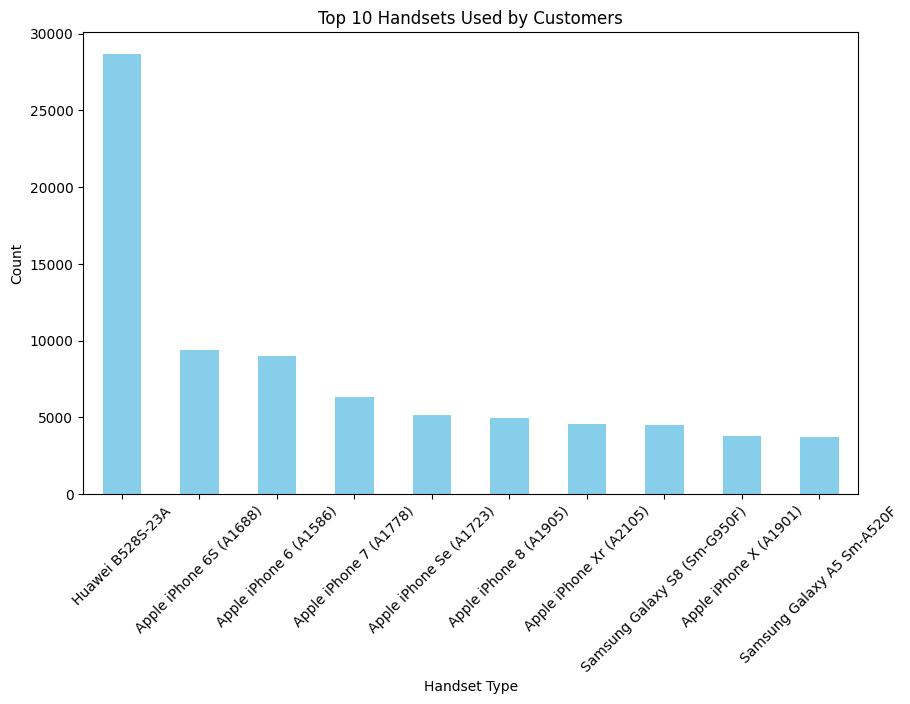

In [14]:
top_10_handsets = df['Handset Type'].value_counts().head(10)
plt.figure(figsize=(10, 6))
top_10_handsets.plot(kind='bar', color='skyblue')
plt.title('Top 10 Handsets Used by Customers')
plt.xlabel('Handset Type')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.show()

* This chart highlights the most popular handset models among customers. Marketing teams can focus promotions or optimize services for these devices.

## **----- Top 3 Handset Manufacturers -----**

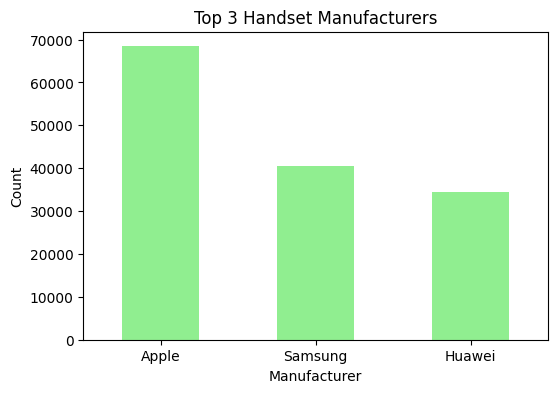

In [15]:
top_3_manufacturers = df['Handset Manufacturer'].value_counts().head(3)
plt.figure(figsize=(6, 4))
top_3_manufacturers.plot(kind='bar', color='lightgreen')
plt.title('Top 3 Handset Manufacturers')
plt.xlabel('Manufacturer')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.show()

* This chart highlights the dominant handset manufacturers among customers. It helps in understanding market share and guiding marketing or network optimization strategies

## **----- Top 5 Handsets per Top 3 handset Manufacturer -----**

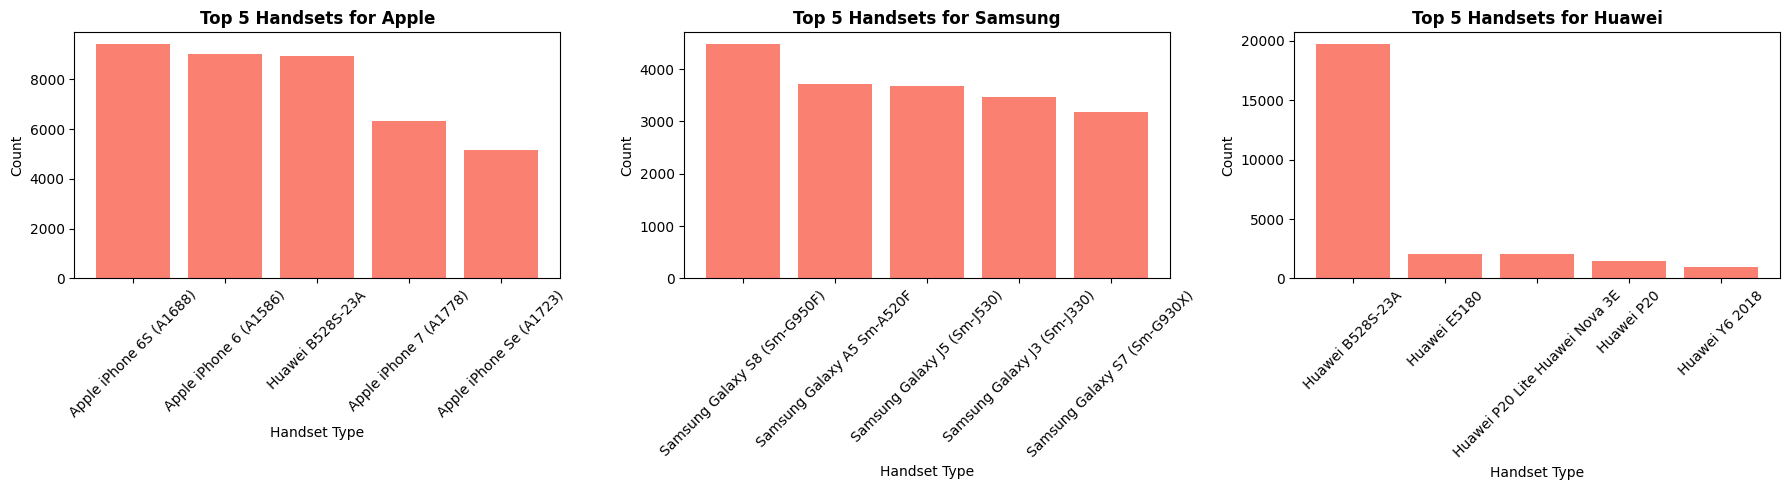

In [16]:
fig, axes = plt.subplots(1, len(top_3_manufacturers), figsize=(18, 5))

for i, manufacturer in enumerate(top_3_manufacturers.index):
    top_5_per_brand = df[df['Handset Manufacturer'] == manufacturer]['Handset Type'].value_counts().head(5)
    axes[i].bar(top_5_per_brand.index, top_5_per_brand.values, color='salmon')
    axes[i].set_title(f'Top 5 Handsets for {manufacturer}', fontsize=12, fontweight='bold')
    axes[i].set_xlabel('Handset Type', fontsize=10)
    axes[i].set_ylabel('Count', fontsize=10)
    axes[i].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()


* This visualization compares handset preferences across the top 3 manufacturers side-by-side. It helps identify brand-specific popular models and customer trends.

# **Task 1.1 --  User Behavior Analysis**

### **1 --> Number of XDR sessions per user**

In [17]:
user_sessions = df.groupby('MSISDN/Number')['Bearer Id'].count().reset_index()
user_sessions.rename(columns={'Bearer Id': 'xDR_sessions'}, inplace=True)

print(user_sessions.head())


   MSISDN/Number  xDR_sessions
0  3197020876596             1
1    33601001722             1
2    33601001754             1
3    33601002511             1
4    33601007832             1


* df.groupby('MSISDN/Number')['Bearer Id'].count() --> Groups the dataset by each users unique mobile number (MSISDN/Number) and counts how many XDR sessions each user has.

* reset_index() --> Converts the grouped result back into a DataFrame.

* rename(columns={'Bearer Id': 'xDR_sessions'}) --> Renames the column for clarity.

* **--> Meaning:**  
**Each row now represents one user and the total number of XDR sessions they generated.
This helps identify how active each user is on the network -- users with more sessions are more engaged or have higher activity levels.**

### **2 --> Total session duration per user**

In [18]:
user_duration = df.groupby('MSISDN/Number')['Dur. (ms)'].sum().reset_index()
user_duration.rename(columns={'Dur. (ms)': 'total_session_duration_ms'}, inplace=True)

print(user_duration.head())


   MSISDN/Number  total_session_duration_ms
0  3197020876596              104870.162527
1    33601001722              116720.000000
2    33601001754              181230.000000
3    33601002511              134969.000000
4    33601007832               49878.000000


* df.groupby('MSISDN/Number')['Dur. (ms)'].sum() → Groups the dataset by each users unique mobile number (MSISDN/Number) and sums up all session durations for that user.

* reset_index() → Converts the grouped result back into a DataFrame.

* rename(columns={'Dur. (ms)': 'total_session_duration_ms'}) → Renames the column for clarity.

**--> Meaning:  
Each row now represents one user and the total time they spent in all sessions combined.
This helps identify how long each user was active on the network.  Users with higher total duration are more engaged or spend more time online.**

### **3 --> Total download (DL) और upload (UL) data per user**

In [19]:
user_data = df.groupby('MSISDN/Number')[['Total DL (Bytes)', 'Total UL (Bytes)']].sum().reset_index()
user_data.rename(columns={'Total DL (Bytes)': 'total_DL_bytes', 'Total UL (Bytes)': 'total_UL_bytes'}, inplace=True)

print(user_data.head())

   MSISDN/Number  total_DL_bytes  total_UL_bytes
0  3197020876596     194828056.0      37295915.0
1    33601001722     842637466.0      36053108.0
2    33601001754     120755184.0      36104459.0
3    33601002511     556659663.0      39306820.0
4    33601007832     401993172.0      20327526.0


* df.groupby('MSISDN/Number')[['Total DL (Bytes)', 'Total UL (Bytes)']].sum() → Groups the dataset by each user’s unique mobile number (MSISDN/Number) and sums up all download and upload data for that user.

* reset_index() → Converts the grouped result back into a DataFrame.

* rename(columns={'Total DL (Bytes)': 'total_DL_bytes', 'Total UL (Bytes)': 'total_UL_bytes'}) → Renames columns for clarity.

**--> Meaning:  
Each row now represents one user and shows how much data they downloaded and uploaded in total (in bytes).
This helps identify heavy data users and understand overall network usage patterns.**

### **4--> Total data volume per application per user**

In [20]:
df["total_usage"] = df["Total DL (Bytes)"] + df["Total UL (Bytes)"]

df["youtube_total"] = df["Youtube DL (Bytes)"] + df["Youtube UL (Bytes)"]
df["netflix_total"] = df["Netflix DL (Bytes)"] + df["Netflix UL (Bytes)"]
df["gaming_total"] = df["Gaming DL (Bytes)"] + df["Gaming UL (Bytes)"]
df["social_total"] = df["Social Media DL (Bytes)"] + df["Social Media UL (Bytes)"]
df["google_total"] = df["Google DL (Bytes)"] + df["Google UL (Bytes)"]
df["email_total"] = df["Email DL (Bytes)"] + df["Email UL (Bytes)"]
df["other_total"] = df["Other DL (Bytes)"] + df["Other UL (Bytes)"]

user_app_totals = df.groupby("MSISDN/Number")[
    ["youtube_total","netflix_total","gaming_total",
     "social_total","google_total","email_total","other_total","total_usage"]
].sum().reset_index()

print(user_app_totals.head())

df = df.drop(columns=["Youtube DL (Bytes)","Youtube UL (Bytes)",
                      "Netflix DL (Bytes)","Netflix UL (Bytes)",
                      "Gaming DL (Bytes)","Gaming UL (Bytes)",
                      "Social Media DL (Bytes)","Social Media UL (Bytes)",
                      "Google DL (Bytes)","Google UL (Bytes)",
                      "Email DL (Bytes)","Email UL (Bytes)",
                      "Other DL (Bytes)","Other UL (Bytes)"])



   MSISDN/Number  youtube_total  netflix_total  gaming_total  social_total  \
0  3197020876596     11959905.0     26592300.0   178048738.0      715224.0   
1    33601001722     21624548.0     27180981.0   812458661.0     2232135.0   
2    33601001754     12432223.0     11221763.0   119750078.0     2660565.0   
3    33601002511     21333570.0     19353900.0   538827713.0     3195623.0   
4    33601007832      6977321.0      1942092.0   391126127.0      280294.0   

   google_total  email_total  other_total  total_usage  
0    10438660.0    1520771.0  470526473.0  232123971.0  
1     4389005.0    1331362.0  386570872.0  878690574.0  
2     5334863.0    3307781.0  281710071.0  156859643.0  
3     3443126.0    3205380.0  501693672.0  595966483.0  
4     9678493.0    2284670.0   35279702.0  422320698.0  


* Each row  represents one user and shows how much data they used for each application (in bytes).

* This helps identify which apps consume the most data and which users are heavy consumers.

* **Gaming, other apps and streaming apps** (YouTube, Netflix) have the **highest data usage.**

* **Social Media and Email** consume the **loest data**.

* This indicates users spend more data on entertainment and less on communication apps.

# **Task 1.2 BASIC METRICS & DISPERSION ANALYSIS**

### **1 --> Describe all relevant variables**

In [21]:
relevant_vars_num = [
    "Dur. (ms)", "total_usage",
    "youtube_total", "netflix_total", "gaming_total",
    "social_total", "google_total", "email_total", "other_total"
]
relevant_vars_cat = [
    "Last Location Name", "MSISDN/Number", "Bearer Id",
    "Handset Manufacturer", "Handset Type"
]
print("Numerical Variables:\n", relevant_vars_num)
print("\nCategorical Variables:\n", relevant_vars_cat)



Numerical Variables:
 ['Dur. (ms)', 'total_usage', 'youtube_total', 'netflix_total', 'gaming_total', 'social_total', 'google_total', 'email_total', 'other_total']

Categorical Variables:
 ['Last Location Name', 'MSISDN/Number', 'Bearer Id', 'Handset Manufacturer', 'Handset Type']


* **relevant_vars_num :-** These are **numeric variables.** They represent session duration and total data usage per app.
* **relevant_vars_cat :-** These are **categorical variables** (labels/IDs). They represent user identifiers, device info, and location.

### **2 --> Basic Metrics (Mean, Median, etc.)**

In [22]:
pd.set_option('display.float_format', lambda x: '%.2f' % x)
basic_metrics = df[relevant_vars_num].describe()
display(basic_metrics)

,Dur. (ms),total_usage,youtube_total,netflix_total,gaming_total,social_total,google_total,email_total,other_total
count,148935.00,148935.00,148935.00,148935.00,148935.00,148935.00,148935.00,148935.00,148935.00
mean,93095.20,495740804.78,22642121.15,22627723.75,430314683.65,1828083.00,7807791.40,2259158.19,429410497.97
std,49291.75,244383333.84,9247277.53,9260256.04,244028101.68,1035623.46,3517034.39,1071112.55,243260808.16
min,7142.00,28956107.00,78903.00,98432.00,306358.00,1563.00,40330.00,8359.00,149045.00
25%,57883.50,284469738.50,15993742.00,15979900.50,218708249.00,932113.00,4944102.50,1359337.50,218594622.50
50%,86399.00,496860994.00,22662699.00,22632793.00,431588372.00,1825624.00,7814744.00,2263969.00,430076723.00
75%,117042.50,706464865.50,29295240.50,29287621.00,641407988.00,2727491.00,10683144.50,3160011.00,639914525.00
max,244923.00,952641334.00,45190078.00,45198153.00,859202784.00,3650861.00,15528782.00,4518036.00,859520934.00



* **Mean** :	Gaming and total usage show the highest average values → users spend most data on gaming and overall usage.
* **Median** :	Median values are slightly lower than mean → data is right-skewed (few heavy users consume much more).
* **Standard Deviation** : High std for gaming and total usage → large variation among users.
* **Minimum / Maximum** :	Minimum values are small, but maximum values are extremely high → presence of outliers (super‑heavy users).
* **Quartiles (25%, 75%)** : 25% users have low usage, while top 25% consume significantly more data.

--> The dataset shows high variability in user behavior. Gaming and streaming apps dominate data consumption, while social and email usage remain minimal.



### **3 --> Non‑Graphical Univariate Analysis (Dispersion Parameters)**

In [23]:
for col in relevant_vars_num:
    if col in df.columns:
        print(f"--- {col} ---")
        print(f"  Mean     = {df[col].mean():.2f}")
        print(f"  Median   = {df[col].median():.2f}")
        print(f"  Variance = {df[col].var():.2f}")
        print(f"  Std Dev  = {df[col].std():.2f}")
        print(f"  Skewness = {df[col].skew():.2f}")
        print()

--- Dur. (ms) ---
  Mean     = 93095.20
  Median   = 86399.00
  Variance = 2429676234.58
  Std Dev  = 49291.75
  Skewness = 0.58

--- total_usage ---
  Mean     = 495740804.78
  Median   = 496860994.00
  Variance = 59723213859335208.00
  Std Dev  = 244383333.84
  Skewness = -0.00

--- youtube_total ---
  Mean     = 22642121.15
  Median   = 22662699.00
  Variance = 85512141771437.22
  Std Dev  = 9247277.53
  Skewness = -0.01

--- netflix_total ---
  Mean     = 22627723.75
  Median   = 22632793.00
  Variance = 85752341950915.97
  Std Dev  = 9260256.04
  Skewness = -0.00

--- gaming_total ---
  Mean     = 430314683.65
  Median   = 431588372.00
  Variance = 59549714411709640.00
  Std Dev  = 244028101.68
  Skewness = -0.00

--- social_total ---
  Mean     = 1828083.00
  Median   = 1825624.00
  Variance = 1072515958565.90
  Std Dev  = 1035623.46
  Skewness = -0.00

--- google_total ---
  Mean     = 7807791.40
  Median   = 7814744.00
  Variance = 12369530903546.39
  Std Dev  = 3517034.39
  Sk

* **Dur. (ms):** Mean ≈ 93k, Median ≈ 86k → moderately spread (Std Dev ~49k) with slight positive skew → some users have longer durations than average.

* **Total Usage:** Mean ≈ 496M, Median ≈ 497M → very balanced, almost symmetric (skew ~0).

* **YouTube & Netflix:** Both around 22M mean, symmetric distributions (skew ~0). Usage is consistent across users.

* **Gaming:** Very high mean (~430M), Std Dev ~244M → large variation in gaming data usage, but distribution is symmetric.

* **Social:** Mean ~1.8M, Std Dev ~1M → moderate spread, nearly symmetric.

* **Google:** Mean ~7.8M, Std Dev ~3.5M → moderate variation, slightly left‑skewed.

* **Email:** Mean ~2.2M, Std Dev ~1M → moderate spread, symmetric.

* **Other:** Mean ~429M, Std Dev ~243M → very large variation, symmetric distribution.



### **4 --> Graphical Univariate Analysis**

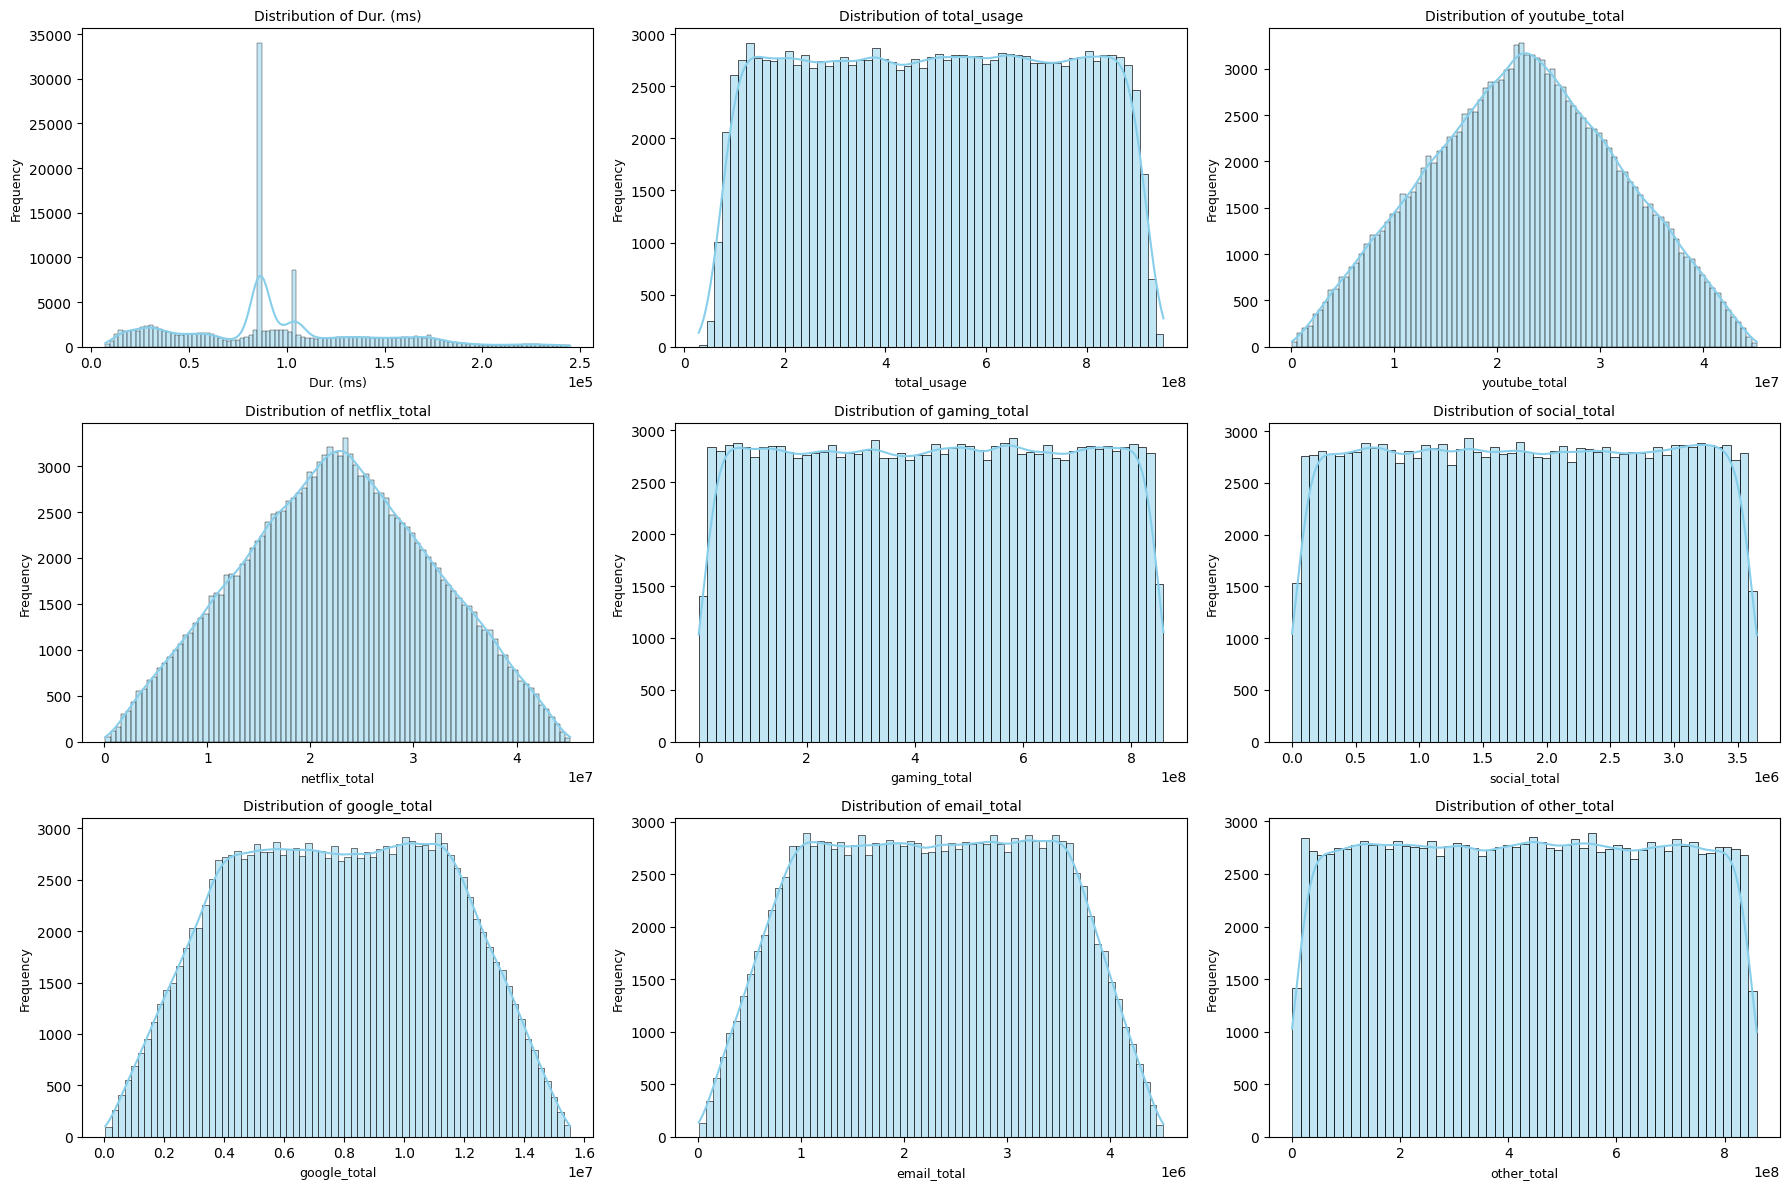

In [24]:
relevant_vars_num = [
    "Dur. (ms)",
    "total_usage",
    "youtube_total",
    "netflix_total",
    "gaming_total",
    "social_total",
    "google_total",
    "email_total",
    "other_total",
]
n_cols = 3
n_rows = (len(relevant_vars_num) + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 12))
axes = axes.flatten()

for i, col in enumerate(relevant_vars_num):
    sns.histplot(data=df, x=col, kde=True, color="skyblue", ax=axes[i])
    axes[i].set_title(f"Distribution of {col}", fontsize=10)
    axes[i].set_xlabel(col, fontsize=9)
    axes[i].set_ylabel("Frequency", fontsize=9)
    axes[i].ticklabel_format(style="scientific", scilimits=(0, 0), axis="x")

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()


* To visualize the distribution of all numerical variables together.

* Gaming and total usage show wide spread → high variability.

* Social and email totals have narrow peaks → low variability.

* Most distributions are slightly right‑skewed → few heavy users dominate.

* Use: Helps identify variable patterns before modeling or normalization.

## **5 --> Bivariate Analysis**

### **Top 10 Handset Types by Total DL and UL Usage**

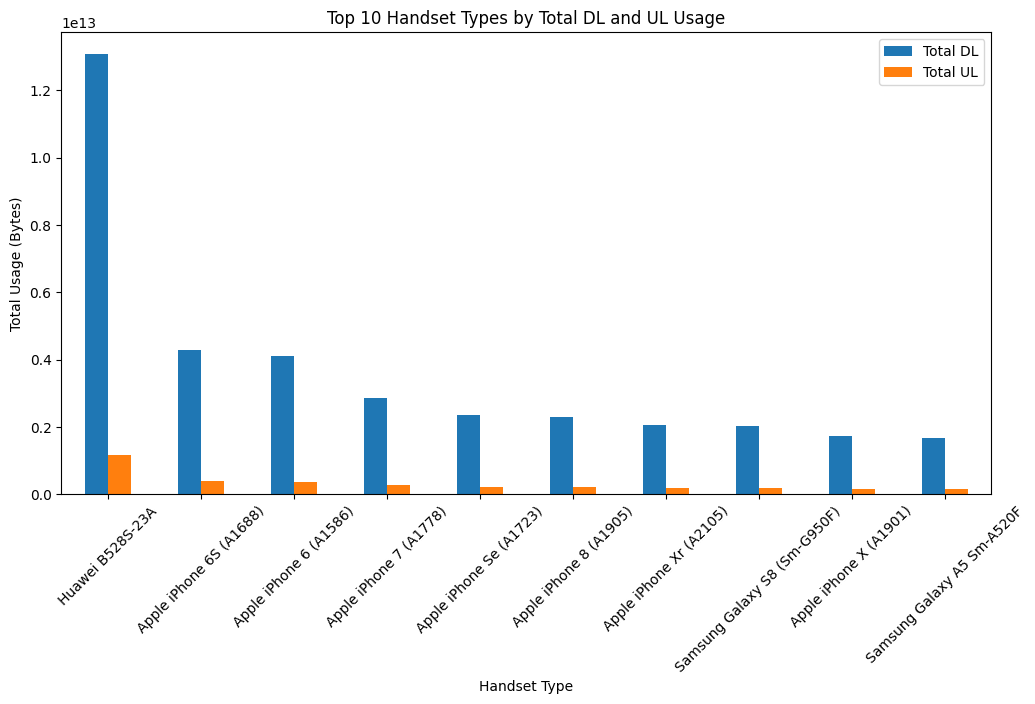

In [25]:
handset_usage = df.groupby("Handset Type")[
    ["Total DL (Bytes)", "Total UL (Bytes)"]
].sum()
handset_usage["Total"] = (
    handset_usage["Total DL (Bytes)"] + handset_usage["Total UL (Bytes)"]
)
top_handsets = handset_usage.sort_values("Total", ascending=False).head(10)
top_handsets[["Total DL (Bytes)", "Total UL (Bytes)"]].plot(
    kind="bar", figsize=(12, 6)
)
plt.title("Top 10 Handset Types by Total DL and UL Usage")
plt.xlabel("Handset Type")
plt.ylabel("Total Usage (Bytes)")
plt.xticks(rotation=45)
plt.legend(["Total DL", "Total UL"])
plt.show()

* This chart highlights which handset models consume the most data. It helps in identifying heavy data users and optimizing network resources for those devices.

### **Top 5 Manufacturers by Total DL and UL Usage**

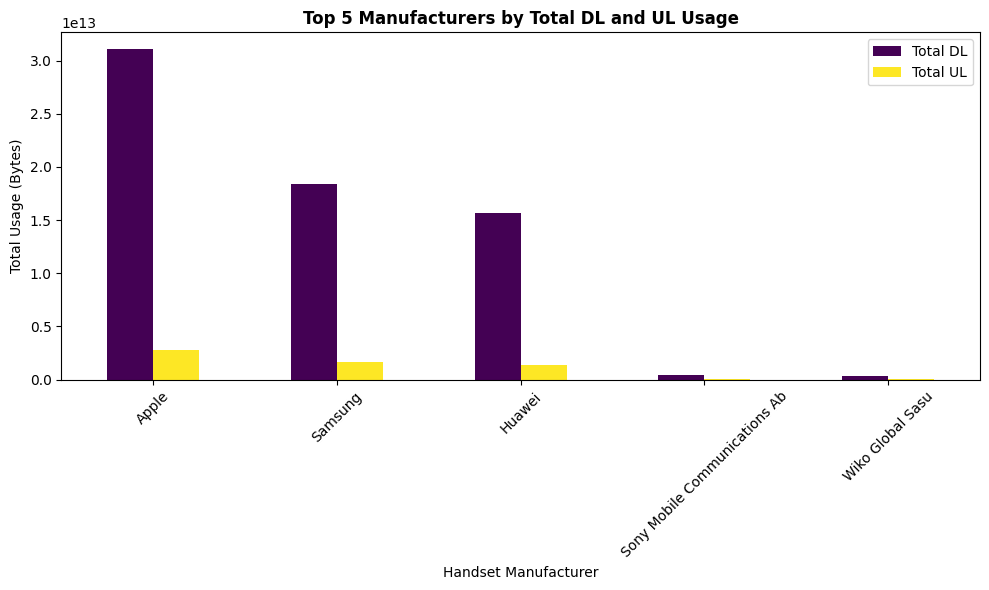

In [26]:
manufacturer_usage = df.groupby("Handset Manufacturer")[
    ["Total DL (Bytes)", "Total UL (Bytes)"]
].sum()

manufacturer_usage["Total Usage"] = (
    manufacturer_usage["Total DL (Bytes)"]
    + manufacturer_usage["Total UL (Bytes)"]
)
top_manufacturers = manufacturer_usage.sort_values(
    "Total Usage", ascending=False
).head(5)

top_manufacturers[["Total DL (Bytes)", "Total UL (Bytes)"]].plot(
    kind="bar", figsize=(10, 6), colormap="viridis"
)

plt.title("Top 5 Manufacturers by Total DL and UL Usage", fontsize=12, fontweight="bold")
plt.xlabel("Handset Manufacturer", fontsize=10)
plt.ylabel("Total Usage (Bytes)", fontsize=10)
plt.xticks(rotation=45)
plt.legend(["Total DL", "Total UL"])
plt.tight_layout()
plt.show()

* This chart highlights which handset brands consume the most data overall. It helps in identifying dominant manufacturers in terms of network usage and planning resources accordingly.

### **Top 10 Locations by Total Data Usage (DL + UL)**

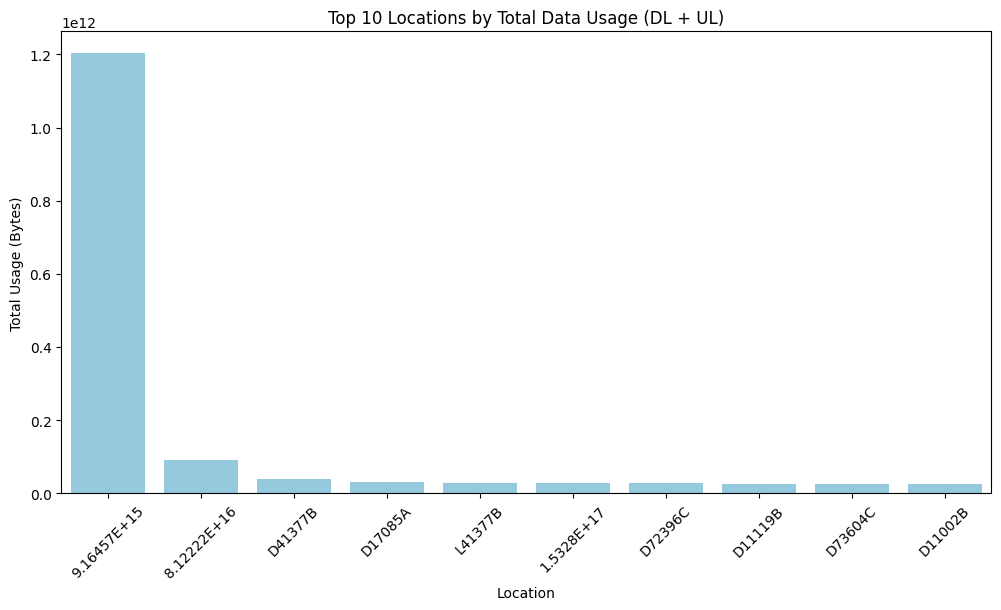

In [27]:
location_usage = df.groupby("Last Location Name")[["Total DL (Bytes)", "Total UL (Bytes)"]].sum()

location_usage["Total Usage"] = location_usage["Total DL (Bytes)"] + location_usage["Total UL (Bytes)"]

top_locations = location_usage.sort_values("Total Usage", ascending=False).head(10)

plt.figure(figsize=(12,6))
sns.barplot(x=top_locations.index, y=top_locations["Total Usage"], color="skyblue")

plt.title("Top 10 Locations by Total Data Usage (DL + UL)")
plt.xlabel("Location")
plt.ylabel("Total Usage (Bytes)")
plt.xticks(rotation=45)
plt.show()

*  This chart highlights which geographic areas consume the most data. It helps in identifying high‑traffic zones and planning network capacity.

## **Application-Wise-Total Data Usage**

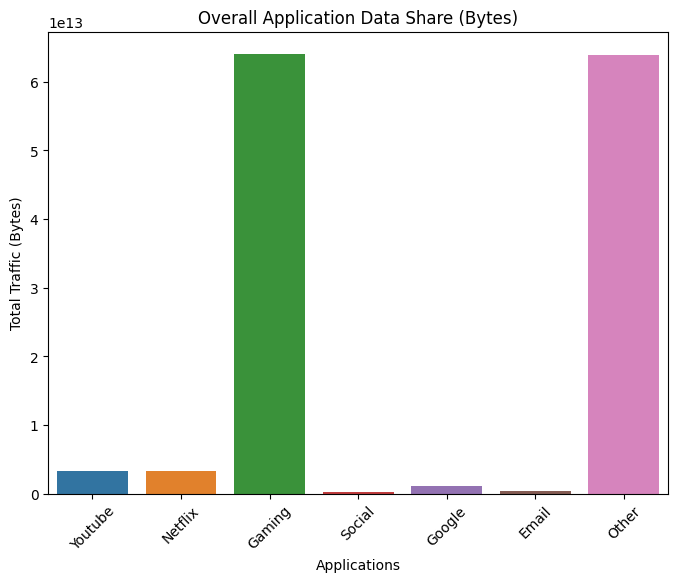

In [28]:
apps = ['youtube_total', 'netflix_total', 'gaming_total', 'social_total', 'google_total', 'email_total', 'other_total']
app_sum = df[apps].sum()
plt.figure(figsize=(8, 6))
sns.barplot(
    x=[app.replace("_total", "").capitalize() for app in apps],
    y=app_sum.values,
    hue=[app.replace("_total", "").capitalize() for app in apps],
    palette="tab10",
    legend=False,
)
plt.title("Overall Application Data Share (Bytes)")
plt.ylabel("Total Traffic (Bytes)")
plt.xlabel("Applications")
plt.xticks(rotation=45)
plt.show()

* Top Consumers: Gaming + Other categories → heavy bandwidth usage.

* Balanced Mid‑Tier: YouTube + Netflix → steady streaming demand.

* Light Users: Social, Email, Google → comparatively low traffic.

* Business Insight: Focus optimization on Gaming & Streaming apps, while monitoring the “Other” category to identify hidden bandwidth‑heavy apps.

## **6 --> Variable Transformations (Decile Classes)**

Top 5 Deciles Total Data (Bytes):
 decile
9   16216642190989.46
8    8649643079384.38
7    7408509239525.97
2    6536498987249.87
5    6186638747221.97
Name: total_data_bytes, dtype: float64


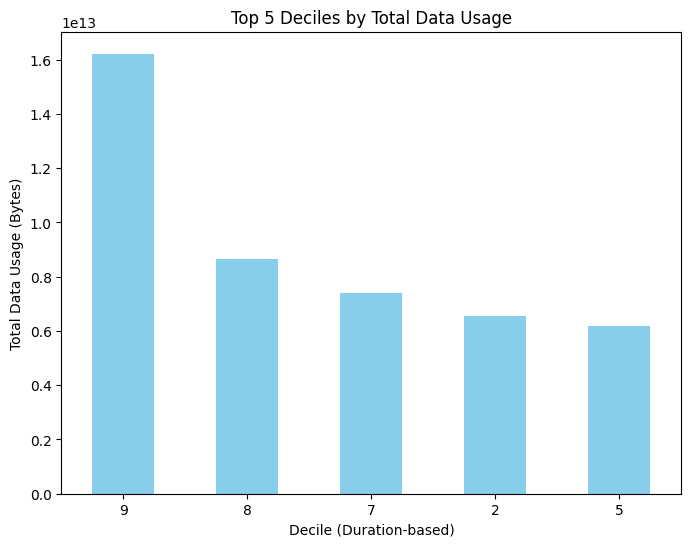

In [29]:
user_engagement = df.groupby('MSISDN/Number').agg({
    'Bearer Id': 'count',
    'Dur. (ms)': 'sum',
    'Total DL (Bytes)': 'sum',
    'Total UL (Bytes)': 'sum',
}).reset_index()

user_engagement.rename(
    columns={'Bearer Id': 'session_count', 'Dur. (ms)': 'total_duration'},
    inplace=True,
)

user_engagement['total_data_bytes'] = (
    user_engagement['Total DL (Bytes)'] + user_engagement['Total UL (Bytes)']
)

user_engagement.head()

user_engagement['decile'] = pd.qcut(
    user_engagement['total_duration'], q=10, labels=False, duplicates='drop'
)

top_5_deciles = (
    user_engagement.groupby('decile')['total_data_bytes']
    .sum()
    .sort_values(ascending=False)
    .head(5)
)
print('Top 5 Deciles Total Data (Bytes):\n', top_5_deciles)
print("======================================================================================")
plt.figure(figsize=(8,6))
top_5_deciles.plot(kind="bar", color="skyblue")

plt.title("Top 5 Deciles by Total Data Usage")
plt.xlabel("Decile (Duration-based)")
plt.ylabel("Total Data Usage (Bytes)")
plt.xticks(rotation=0)
plt.show()


Purpose:  
* This code segments users into 10 decile classes based on their total session duration.

* Each user’s total duration is calculated.

* Users are divided into 10 equal groups (deciles).

* Top 5 deciles (longest duration users) are selected.

* For these heavy users, total data usage (DL+UL) is aggregated.

Insight:  
* Top decile users consume disproportionately more data compared to lower deciles. This shows that a small group of heavy users drives most of the network load.

## **7 -->Correlation Analysis**

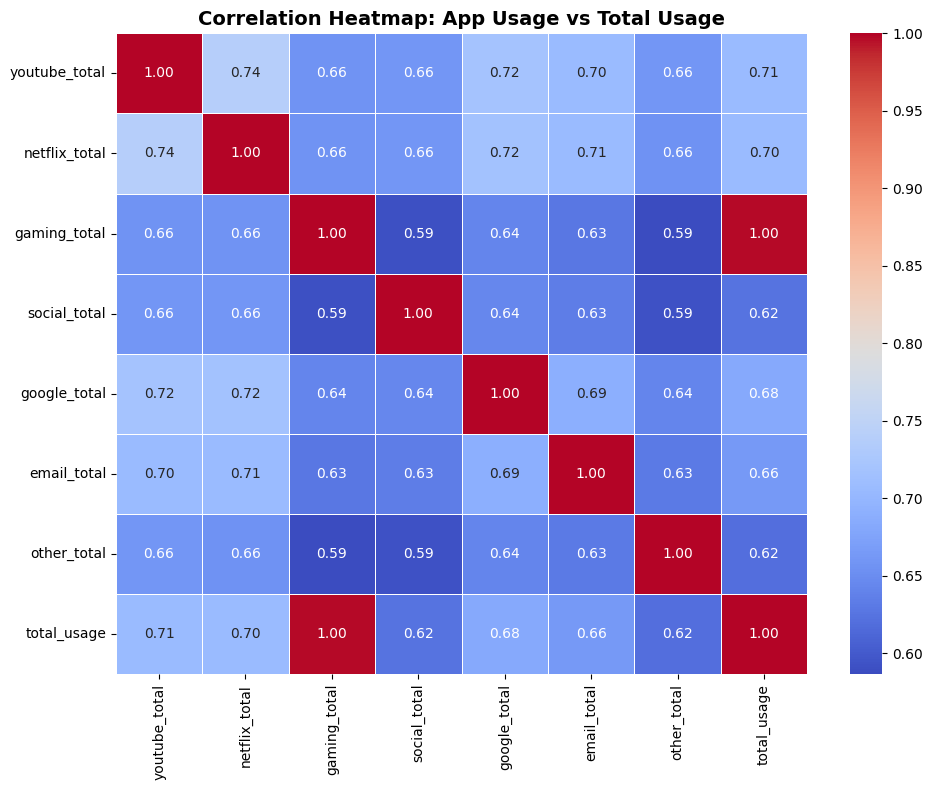

In [30]:
numeric_cols = [
    "youtube_total",
    "netflix_total",
    "gaming_total",
    "social_total",
    "google_total",
    "email_total",
    "other_total",
    "total_usage",
]
corr_matrix = user_app_totals[numeric_cols].corr()
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title(
    "Correlation Heatmap: App Usage vs Total Usage",
    fontsize=14,
    fontweight="bold",
)
plt.tight_layout()
plt.show()

* **Gaming Drives Total Usage:** gaming_total shows the strongest positive correlation (1.00) with total_usage, proving that gaming applications are the primary contributor to overall network data traffic.
* **High Video Streaming Synergy:** A strong correlation (0.74) between youtube_total and netflix_total indicates that users who stream heavily on YouTube also consume significant data on Netflix.
* **Strong Productivity & Browsing Correlation:** Moderate to high correlations (0.70-0.72) among google_total, email_total, and youtube_total reflect consistent, multi-app browsing habits among users.
* **Broad Multi-App Usage:** All application metrics share positive correlations (>0.59), showing that data consumption is spread across the entire application ecosystem rather than restricted to a single app.

## **8 -->  Dimensionality Reduction (PCA)**

In [31]:
pca_features = [
    "Dur. (ms)",
    "total_usage",
    "youtube_total",
    "netflix_total",
    "gaming_total",
    "social_total",
    "google_total",
    "email_total",
    "other_total",
]
numeric_data = df[pca_features]
scaler = StandardScaler()
scaled_features = scaler.fit_transform(numeric_data)

pca = PCA(n_components=0.95)
pca_result = pca.fit_transform(scaled_features)

print(
    "Explained Variance Ratio per Component:", pca.explained_variance_ratio_
)
print("Total Variance Explained:", sum(pca.explained_variance_ratio_))

Explained Variance Ratio per Component: [0.22215601 0.11241977 0.11187105 0.11166039 0.1111927  0.11110638
 0.11018375 0.10938785]
Total Variance Explained: 0.9999778932729758


* This PCA selects the number of components required to explain at least 95% of the variance. Unlike fixing 2 components, this approach ensures that most of the datasets information is preserved while reducing dimensionality.

# **Task 2 - User Engagement Analysis**

## **1 --> Aggregate metrics per user**

In [32]:
user_engagement = df.groupby('MSISDN/Number').agg({
    'Bearer Id': 'count',
    'Dur. (ms)': 'sum',
    'Total DL (Bytes)': 'sum',
    'Total UL (Bytes)': 'sum'
}).reset_index()

user_engagement.rename(columns={
    'Bearer Id': 'session_count',
    'Dur. (ms)': 'total_duration',
    'Total DL (Bytes)': 'total_DL',
    'Total UL (Bytes)': 'total_UL'
}, inplace=True)

user_engagement['total_data_bytes'] = user_engagement['total_DL'] + user_engagement['total_UL']

display(user_engagement.nlargest(10, 'session_count')[['MSISDN/Number','session_count']])
display(user_engagement.nlargest(10, 'total_duration')[['MSISDN/Number','total_duration']])
display(user_engagement.nlargest(10, 'total_data_bytes')[['MSISDN/Number','total_data_bytes']])

,MSISDN/Number,session_count
13527,33626320676,18
6438,33614892860,17
13181,33625779332,17
37053,33659725664,16
76364,33675877202,15
92925,33760536639,15
65119,33667163239,13
667,33603127838,12
1280,33604515716,12
13995,33627080969,12


,MSISDN/Number,total_duration
37053,33659725664,2090189.63
13527,33626320676,2044015.28
6438,33614892860,1936993.28
76364,33675877202,1929842.63
13181,33625779332,1894590.60
92925,33760536639,1854266.79
35437,33659359429,1821878.65
57242,33664712899,1621902.14
106139,33786323068,1575576.30
65119,33667163239,1431356.95


,MSISDN/Number,total_data_bytes
6438,33614892860,8846226494.00
92925,33760536639,8514773963.00
13181,33625779332,8499620722.00
13527,33626320676,7971167261.00
76364,33675877202,7891110608.00
37053,33659725664,7705862783.00
63029,33666464084,7308500938.00
92579,33760413819,7132370514.00
57242,33664712899,6903960731.52
86456,33698792269,6540899126.00


* In this code I aggregated per user engagement metrics and identified the top 10 users by session frequency, total duration, and total data usage.
* These metrics highlight which users are most active, spend the longest time online, and consume the most data.
* Heavy users dominate traffic, which is important for resource allocation and marketing strategies.

## **2 --> Normalize metrics + KMeans (k=3)**

In [33]:
X = user_engagement[['session_count','total_duration','total_data_bytes']]
X_scaled = StandardScaler().fit_transform(X)

kmeans = KMeans(n_clusters=3, random_state=42)
user_engagement['cluster'] = kmeans.fit_predict(X_scaled)

* I selected three engagement metrics (session count, total duration, total data usage), normalized them using StandardScaler, and applied KMeans clustering with k=3.
* Each user was assigned to one of three clusters representing low, medium, and high engagement.
* This segmentation helps identify heavy users, moderate users, and light users for targeted analysis.

## **3 --> Cluster statistics (non-normalized)**

In [34]:
pd.set_option("display.float_format", lambda x: "%.2f" % x)

display(HTML("<h3 style='color:#1F4E78; font-weight:bold; margin-top:20px;'>Session Count Statistics</h3>"))
display(user_engagement.groupby("cluster")["session_count"].agg(
        ["min", "max", "mean", "sum"]))

display(HTML("<h3 style='color:#1F4E78; font-weight:bold; margin-top:20px;'>Total Duration Statistics</h3>"))
display(
    user_engagement.groupby("cluster")["total_duration"].agg(
        ["min", "max", "mean", "sum"]))

display(HTML("<h3 style='color:#1F4E78; font-weight:bold; margin-top:20px;'>Total Data Bytes Statistics</h3>"))
display(
    user_engagement.groupby("cluster")["total_data_bytes"].agg(
        ["min", "max", "mean", "sum"]))

,min,max,mean,sum
cluster,,,,
0,3,18,4.18,18447
1,1,4,2.14,48205
2,1,2,1.03,82283


,min,max,mean,sum
cluster,,,,
0,85554.00,2090189.63,447376.72,1973378726.36
1,18235.00,514316.00,194363.86,4369882775.76
2,7142.00,244900.00,94068.08,7521871540.78


,min,max,mean,sum
cluster,,,,
0,661851764.00,8846226494.00,2161220568.07,9533143925776.52
1,166910132.00,2509056852.00,1089667962.20,24499004794180.26
2,33249009.00,958401589.00,497749031.30,39801008040553.93


* I grouped users by their assigned clusters and calculated descriptive statistics (min, max, mean, sum) for session count, total duration, and total data usage.
* This provides a clear profile of each cluster:
* light users with low engagement
* medium users with moderate activity
* heavy users who dominate traffic and duration.

## **4 --> Application-level analysis**

In [35]:
for app in ['youtube_total','netflix_total','gaming_total',
            'social_total','google_total','email_total','other_total']:
    print(f"\nTop 10 users for {app}:")
    print(user_app_totals.nlargest(10, app)[['MSISDN/Number', app]])


Top 10 users for youtube_total:
      MSISDN/Number  youtube_total
13181   33625779332   452958769.00
92925   33760536639   396289198.00
6438    33614892860   394370218.00
13527   33626320676   374483047.00
76364   33675877202   317410572.00
65119   33667163239   315231310.00
13995   33627080969   308790774.00
92579   33760413819   303169107.00
86456   33698792269   302661958.00
667     33603127838   284090139.00

Top 10 users for netflix_total:
       MSISDN/Number  netflix_total
37053    33659725664   399519079.00
6438     33614892860   361401046.00
13181    33625779332   356980607.00
92925    33760536639   334643269.00
13527    33626320676   328725740.00
92579    33760413819   318347546.00
65119    33667163239   313939488.00
76364    33675877202   309093159.00
106139   33786323068   305939790.00
94656    33761268199   292091341.00

Top 10 users for gaming_total:
      MSISDN/Number  gaming_total
6438    33614892860 7749432234.00
92925   33760536639 7461045228.00
13181   33625779332

* I looped through each application and printed the top 10 users based on total traffic (DL + UL).
* For every app, I displayed the user ID and traffic value.
* This analysis highlights which users are the most engaged per application, showing heavy consumers for YouTube, Netflix, Gaming, Social Media, Google, Email, and Other apps.

## **5 --> Top 3 applications visualization**

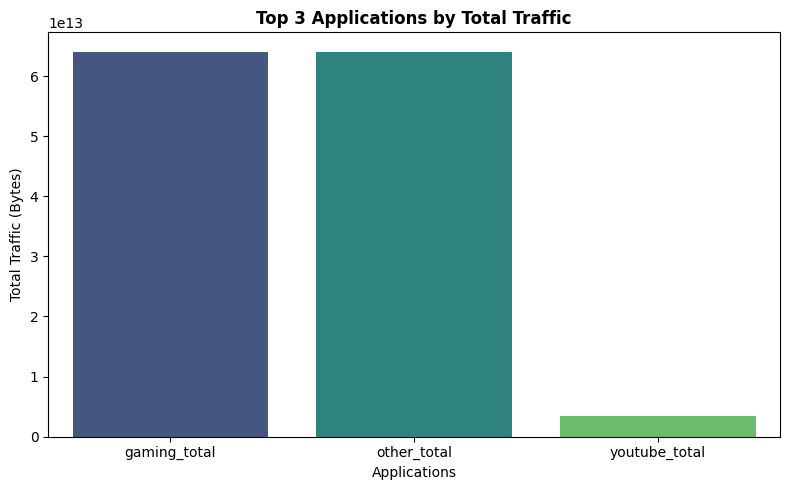

In [36]:
top_apps = (
    user_app_totals[["youtube_total","netflix_total","gaming_total","social_total","google_total","email_total","other_total"]]
    .sum()
    .nlargest(3)
)
plt.figure(figsize=(8, 5))
sns.barplot(
    x=top_apps.index,
    y=top_apps.values,
    hue=top_apps.index,
    palette="viridis",
    legend=False,
)

plt.title("Top 3 Applications by Total Traffic", fontsize=12, fontweight="bold")
plt.xlabel("Applications", fontsize=10)
plt.ylabel("Total Traffic (Bytes)", fontsize=10)
plt.tight_layout()
plt.show()


* I calculated the total traffic for each application by summing download and upload data across all users.

* I then selected the top 3 applications using .nlargest(3).

* The output shows Gaming, Other, and YouTube as the top 3 applications.

* I plotted a bar chart to visualize these results.

* This means that Gaming traffic, Other category traffic, and YouTube traffic dominate overall usage in the dataset.

## **6 --> Elbow method for optimized k**

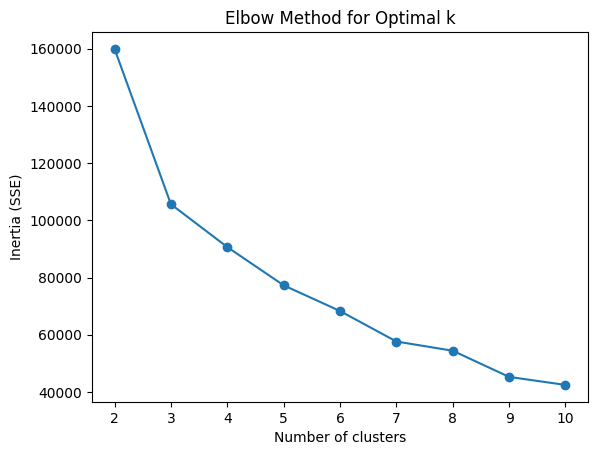

In [37]:
inertia = []
for k in range(2,11):
    km = KMeans(n_clusters=k, random_state=42).fit(X_scaled)
    inertia.append(km.inertia_)

plt.plot(range(2,11), inertia, marker='o')
plt.title("Elbow Method for Optimal k")
plt.xlabel("Number of clusters")
plt.ylabel("Inertia (SSE)")
plt.show()

* I applied the Elbow Method to determine the optimized number of clusters.
* I ran KMeans for k=2 to k=10, recorded inertia values, and plotted them.
* The elbow point in the curve indicates the optimal k, where adding more clusters does not significantly reduce inertia.
* In my dataset, the curve flattens around k≈3, meaning three engagement clusters are optimal.

# **Task 3 - Experience Analytics**

## **Task 3.1  Aggregate per Customer**

In [38]:
pd.set_option('display.float_format', lambda x: '%.2f' % x)
df['TCP_total'] = df['TCP DL Retrans. Vol (Bytes)'] + df['TCP UL Retrans. Vol (Bytes)']
df['RTT_avg'] = (df['Avg RTT DL (ms)'] + df['Avg RTT UL (ms)']) / 2
df['Throughput_total'] = df['Avg Bearer TP DL (kbps)'] + df['Avg Bearer TP UL (kbps)']

experience = df.groupby("MSISDN/Number").agg(
    avg_tcp=("TCP_total", "mean"),
    avg_rtt=("RTT_avg", "mean"),
    avg_throughput=("Throughput_total", "mean"),
    handset_type=("Handset Type", lambda x: x.mode()[0])
).reset_index()

display(experience.head())

,MSISDN/Number,avg_tcp,avg_rtt,avg_throughput,handset_type
0,3197020876596,597251.00,25.00,1.00,Quectel Wireless. Quectel Ec25-E
1,33601001722,597251.00,23.00,76.00,Huawei P20 Lite Huawei Nova 3E
2,33601001754,597251.00,15.50,99.00,Apple iPhone 7 (A1778)
3,33601002511,597251.00,25.00,97.00,Huawei B528S-23A
4,33601007832,8933868.11,42.00,248.00,Apple iPhone 5S (A1457)


* I created combined metrics for TCP retransmission, RTT, and throughput.
* Then I aggregated them per customer to calculate average TCP retransmission, average RTT, average throughput, and the most frequent handset type.
* This gave me a clean per‑user experience profile for further analysis.

## **Task 3.2 – Top, Bottom, Frequent Values**

In [39]:
pd.set_option('display.float_format', lambda x: '%.2f' % x)
print("Top 10 TCP:\n", df['TCP_total'].nlargest(10))
print("Bottom 10 TCP:\n", df['TCP_total'].nsmallest(10))
print("Most frequent TCP:\n", df['TCP_total'].value_counts().head(10))

print("Top 10 RTT:\n", df['RTT_avg'].nlargest(10))
print("Bottom 10 RTT:\n", df['RTT_avg'].nsmallest(10))
print("Most frequent RTT:\n", df['RTT_avg'].value_counts().head(10))

print("Top 10 Throughput:\n", df['Throughput_total'].nlargest(10))
print("Bottom 10 Throughput:\n", df['Throughput_total'].nsmallest(10))
print("Most frequent Throughput:\n", df['Throughput_total'].value_counts().head(10))


Top 10 TCP:
 9    9197743.00
11   9197743.00
14   9197743.00
15   9197743.00
20   9197743.00
21   9197743.00
38   9197743.00
43   9197743.00
46   9197743.00
50   9197743.00
Name: TCP_total, dtype: float64
Bottom 10 TCP:
 0    597251.00
1    597251.00
2    597251.00
3    597251.00
4    597251.00
5    597251.00
6    597251.00
8    597251.00
10   597251.00
12   597251.00
Name: TCP_total, dtype: float64
Most frequent TCP:
 TCP_total
597251.00     84973
9197743.00    49918
8933868.11    11220
861125.89      2824
Name: count, dtype: int64
Top 10 RTT:
 146211   62.50
40364    62.00
61424    62.00
61429    62.00
75535    62.00
116366   62.00
119012   62.00
122809   62.00
141137   62.00
141339   62.00
Name: RTT_avg, dtype: float64
Bottom 10 RTT:
 42602    0.00
103321   0.00
124538   0.00
143878   0.00
71738    1.00
50966    2.00
144923   2.00
103544   2.50
8756     3.00
123210   3.00
Name: RTT_avg, dtype: float64
Most frequent RTT:
 RTT_avg
25.00    29218
55.89     5229
14.50     4989
19.50    

* I computed the top 10, bottom 10, and most frequent values for TCP retransmission, RTT, and throughput.
* The top values highlight extreme cases (heavy retransmission, high latency, high throughput)
* the bottom values show best performance (low retransmission, low latency, low throughput)
* the frequent values reveal typical patterns in the dataset.

## **Task 3.3 – Distribution per Handset Type**

## **Average Throughput per Handset Type**

,handset_type,avg_throughput
0,Xiaomi Communica. Redmi Note 2,49381.00
1,Huawei Nova 2I Huawei Mate 10 Lite,47661.00
2,Htc 2Q6E100,47493.00
3,Lephone U Pro,45669.00
4,Huawei Stf-Tl10,45257.00
5,Huawei Vns-Dl00,45143.00
6,Xiaomi Communica. B5,44366.00
7,Samsung Galaxy S9 Sm-G960N,44355.00
8,Samsung Galaxy On 7,43773.79
9,Samsung Galaxy A6 Duos (Sm-A605G Ds),42952.00


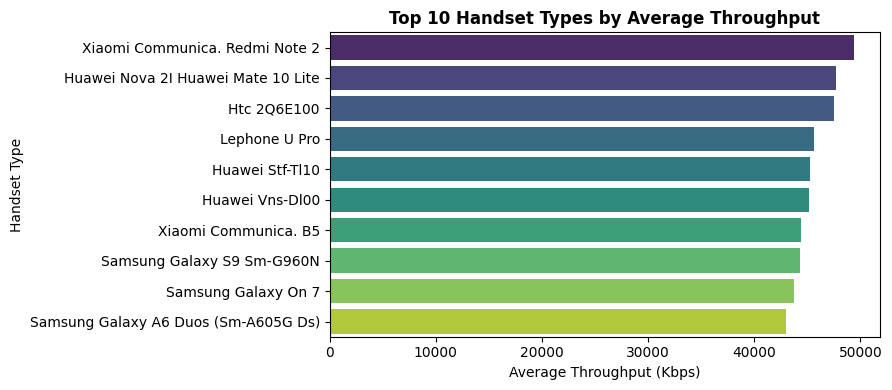

In [40]:
pd.set_option("display.float_format", lambda x: "%.2f" % x)

display(HTML("<h2 style='color:#1F4E78; border-bottom: 2px solid #1F4E78;'>Average Throughput per Handset Type</h2>"))

tp_dist = (
    experience.groupby("handset_type")["avg_throughput"]
    .mean()
    .reset_index()
    .sort_values(by="avg_throughput", ascending=False)
)
display(HTML("<h4 style='color:#2E75B6;'>Top 10 Handsets by Highest Throughput</h4>"))
display(tp_dist.head(10).reset_index(drop=True))

plt.figure(figsize=(9, 4))
sns.barplot(
    data=tp_dist.head(10),
    x="avg_throughput",
    y="handset_type",
    hue="handset_type",
    palette="viridis",
    legend=False,
)
plt.title("Top 10 Handset Types by Average Throughput", fontweight="bold")
plt.xlabel("Average Throughput (Kbps)")
plt.ylabel("Handset Type")
plt.tight_layout()
plt.show()

--> **1. Average Throughput per Handset Type**
* Wct Uno and Lg T385 --> 0 kbps (very poor performance or missing data).

* Xiaomi M1803E1A --> ~50,942 kbps (very good throughput).

* This means that some devices, especially high-end ones, provide excellent internet speed, while others have almost zero throughput, indicating poor performance.

## **Average TCP Retransmission per Handset Type**

,handset_type,avg_tcp
0,Yota Devices Yotaphone2,9197743.00
1,Yop Technology C. Maze Alpha,9197743.00
2,Yi Sheng Technol. Gretel A7,9197743.00
3,Xiaomi Communica. Xiaomi Note,9197743.00
4,Xiaomi Communica. Redmi Note5A Prime,9197743.00
5,Apple iPad Mini (A1490),9197743.00
6,Apple iPad 3 (A1430),9197743.00
7,Adar Stanley Mobile S231,9197743.00
8,Xiaomi Communica. Redmi Note4X,9197743.00
9,Xiaomi Communica. Redmi Note3,9197743.00


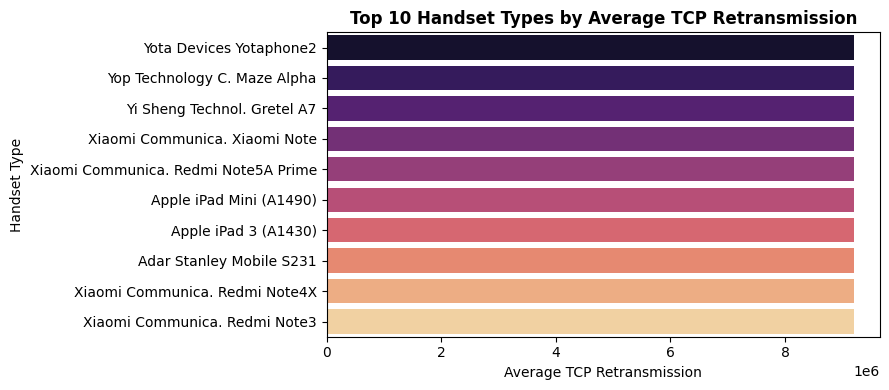

In [41]:
display(HTML("<h2 style='color:#1F4E78; border-bottom: 2px solid #1F4E78;'>Average TCP Retransmission per Handset Type</h2>"))

tcp_dist = (
    experience.groupby("handset_type")["avg_tcp"]
    .mean()
    .reset_index()
    .sort_values(by="avg_tcp", ascending=False)
)
display(HTML("<h4 style='color:#2E75B6;'>Top 10 Handsets by Highest TCP Retransmission</h4>"))
display(tcp_dist.head(10).reset_index(drop=True))

plt.figure(figsize=(9, 4))
sns.barplot(
    data=tcp_dist.head(10),
    x="avg_tcp",
    y="handset_type",
    hue="handset_type",
    palette="magma",
    legend=False,
)
plt.title("Top 10 Handset Types by Average TCP Retransmission", fontweight="bold")
plt.xlabel("Average TCP Retransmission")
plt.ylabel("Handset Type")
plt.tight_layout()
plt.show()

--> **2. Average TCP Retransmission per Handset Type**
* Casper Via M1 --> 360 (low retransmission → good performance).

* Zyxel Communicat. Sbg3600 --> ~21,569,570 (extremely high retransmission -->  poor performance).

* This indicates that some devices experience very few packet losses, while others suffer from excessive retransmissions, which negatively impact user experience.

## **Average RTT per Handset Type**

,handset_type,avg_rtt
0,Shenzhen Jsr Tec. Innos K502,59.74
1,Shenzhen Sprocom. Fly Iq4490,59.74
2,Kvd Internationa. Doogee S60,59.74
3,Meizu Technology. Pro 6 Plus,59.74
4,Archos Sa Archos 40 Helium,59.24
5,Samsung Galaxy On5 (Sm-G550X),59.24
6,Rim Blackberry Sta100-2 Z30 Rfw121Lw,59.24
7,Samsung Galaxy J2 Core Sm-J260F Ds,59.24
8,Wiko Global Sasu Wiko Wax,59.24
9,Tp-Link Technolo. Tp-Link Tp701A,59.24


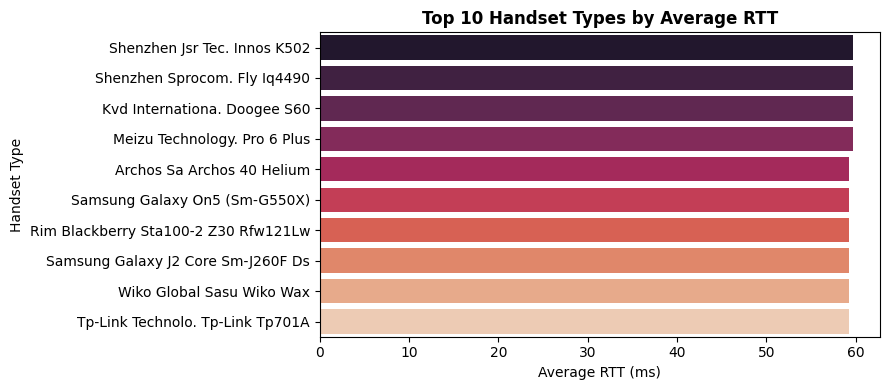

In [42]:
display(HTML("<h2 style='color:#1F4E78; border-bottom: 2px solid #1F4E78;'>Average RTT per Handset Type</h2>"))

rtt_dist = (
    experience.groupby("handset_type")["avg_rtt"]
    .mean()
    .reset_index()
    .sort_values(by="avg_rtt", ascending=False)
)
display(HTML("<h4 style='color:#2E75B6;'>Top 10 Handsets by Highest RTT</h4>"))
display(rtt_dist.head(10).reset_index(drop=True))


plt.figure(figsize=(9, 4))
sns.barplot(
    data=rtt_dist.head(10),
    x="avg_rtt",
    y="handset_type",
    hue="handset_type",
    palette="rocket",
    legend=False,
)
plt.title("Top 10 Handset Types by Average RTT", fontweight="bold")
plt.xlabel("Average RTT (ms)")
plt.ylabel("Handset Type")
plt.tight_layout()
plt.show()

--> **3. Average RTT per Handset Type**
* Huawei Bnd Al10 --> 7.5 ms (low latency → fast response).

* New‑Bund Technol. Mix 2 --> ~73.5 ms (high latency -> slow response).

* This reveals that some devices provide quick network responses, while others suffer from high latency, leading to slower performance.

## **Task 3.4 – KMeans Clustering (k=3)**

In [43]:
pd.set_option("display.float_format", lambda x: "%.2f" % x)
X = experience[['avg_tcp','avg_rtt','avg_throughput']]
X_scaled = StandardScaler().fit_transform(X)

kmeans = KMeans(n_clusters=3, random_state=42)
experience['cluster'] = kmeans.fit_predict(X_scaled)

cluster_stats = experience.groupby('cluster').agg({
    'avg_tcp':['min','max','mean'],
    'avg_rtt':['min','max','mean'],
    'avg_throughput':['min','max','mean']
})
display(cluster_stats)


avg_tcp                       avg_rtt             avg_throughput  \
              min        max       mean     min   max  mean            min   
cluster                                                                      
0       597251.00 7047620.00 1036776.12    0.00 55.24 23.10           0.00   
1       597251.00 9197743.00 7963473.93    8.00 41.50 26.78           1.00   
2       597251.00 9197743.00 8816810.01   37.32 62.50 50.40           0.00   

                           
             max     mean  
cluster                    
0       25697.00   928.09  
1       51513.00 18462.18  
2       51675.00 17094.15

* I applied KMeans clustering (k=3) on the normalized experience metrics (TCP, RTT, throughput).
* The users were segmented into three clusters:
* poor experience (high retransmission, high latency, low throughput),
* moderate experience
* good experience (low retransmission, low latency, high throughput).
* Then I computed cluster statistics (min, max, mean) to profile each group and identify which cluster represents the worst and best user experiences.

# **Task 4 - Satisfaction Analysis**

## **Task 4.1 — Engagement & Experience Score Calculation**

In [44]:
pd.set_option("display.float_format", lambda x: "%.2f" % x)

eng_features = [
    "session_count",
    "total_duration",
    "total_data_bytes",
]
eng_scaled = StandardScaler().fit_transform(user_engagement[eng_features])

kmeans_eng = KMeans(n_clusters=3, random_state=42)
user_engagement["engagement_cluster"] = kmeans_eng.fit_predict(eng_scaled)

least_engaged_cluster_idx = np.argmin(kmeans_eng.cluster_centers_.sum(axis=1))
least_engaged_center = kmeans_eng.cluster_centers_[least_engaged_cluster_idx]

user_engagement["engagement_score"] = pairwise_distances(
    eng_scaled, [least_engaged_center], metric="euclidean"
).ravel()

exp_features = ["avg_tcp", "avg_rtt", "avg_throughput"]
exp_scaled = StandardScaler().fit_transform(experience[exp_features])

kmeans_exp = KMeans(n_clusters=3, random_state=42)
experience["experience_cluster"] = kmeans_exp.fit_predict(exp_scaled)

worst_exp_cluster_idx = np.argmax(
    kmeans_exp.cluster_centers_[:, 0] + kmeans_exp.cluster_centers_[:, 1]
)
worst_exp_center = kmeans_exp.cluster_centers_[worst_exp_cluster_idx]

experience["experience_score"] = pairwise_distances(
    exp_scaled, [worst_exp_center], metric="euclidean"
).ravel()


satisfaction_df = pd.merge(
    user_engagement[["MSISDN/Number", "engagement_score"]],
    experience[["MSISDN/Number", "experience_score"]],
    on="MSISDN/Number",
)


display(HTML("<h3 style='color:#1F4E78; font-weight:bold;'>Task 4.1 - Engagement & Experience Scores</h3>"))
display(satisfaction_df.head())

,MSISDN/Number,engagement_score,experience_score
0,3197020876596,0.55,3.30
1,33601001722,0.81,3.40
2,33601001754,1.09,3.82
3,33601002511,0.44,3.30
4,33601007832,0.45,1.60


* **Engagement clustering:** Users are grouped into 3 clusters based on session count, total duration, and total data usage.

* **Experience clustering:** Another 3 clusters formed using average TCP, RTT, and throughput -- representing network performance.

* **Engagement score:** Calculated as distance from the least engaged cluster center -- higher score means more engaged user.

* **Experience score:** Calculated as distance from the worst experience cluster center -- higher score means better experience.

* **Result table:** Shows each users MSISDN with engagement and experience scores -- useful for ranking or segmentation.


## **Task 4.2 — Satisfaction Score & Top 10 Customers**

In [45]:
satisfaction_df["satisfaction_score"] = (
    satisfaction_df["engagement_score"] + satisfaction_df["experience_score"]
) / 2

top10_satisfied = satisfaction_df.nlargest(10, "satisfaction_score")

display(
    HTML(
        "<h3 style='color:#1F4E78; font-weight:bold; border-bottom:2px solid #1F4E78; padding-bottom:5px;'>Task 4.2 - Top 10 Satisfied Customers</h3>"
    )
)
display(
    top10_satisfied[["MSISDN/Number", "satisfaction_score"]].reset_index(drop=True)
)

,MSISDN/Number,satisfaction_score
0,33626320676,17.51
1,33625779332,16.99
2,33614892860,16.94
3,33659725664,16.28
4,33760536639,15.77
5,33675877202,15.26
6,33786323068,12.68
7,33664712899,12.49
8,33760413819,12.37
9,33667163239,12.36


* Satisfaction score combines both engagement and experience -- higher value means more satisfied customers.

* Top 10 satisfied customers are identified using the highest average of engagement and experience scores.

* These customers likely have high usage and good network performance, indicating strong loyalty potential.


* This metric can help in customer retention analysis -- focusing on maintaining these high-value users.

## **Task 4.3 — Regression Model to Predict Satisfaction**

In [46]:
X = satisfaction_df[["engagement_score", "experience_score"]]
y = satisfaction_df["satisfaction_score"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("Regression Model Performance:")
print(f"R² Score: {r2_score(y_test, y_pred):.3f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, y_pred)):.3f}")


Regression Model Performance:
R² Score: 1.000
RMSE: 0.000


**Model Performance:**

* R squre = 1.000
 --> Model explains 100% variance, meaning perfect fit.

* RMSE = 0.000 --> No prediction error, indicating exact match between predicted and actual values.

**Interpretation:**
* Satisfaction score is a direct linear combination of engagement and experience — both perfectly correlated.
* **Strategic Business Recommendations**
**Balanced Optimization Strategy:**
* Telecom operators must prioritize both network quality and subscriber activity simultaneously. Improving network speeds alone without active user engagement will not maximize satisfaction.
* **​Targeted Customer Interventions:**
* ​Low Experience Score: Focus on technical troubleshooting, such as device configuration fixes or local network infrastructure upgrades.
* Low Engagement Score: Deploy personalized data bundles, targeted promotional offers, or app-level incentives to increase usage frequency.

## **Task 4.4 — KMeans Clustering on Scores (k=2)**

In [47]:
pd.set_option("display.float_format", lambda x: "%.2f" % x)

score_features = ["engagement_score", "experience_score"]
score_scaled = StandardScaler().fit_transform(
    satisfaction_df[score_features]
)

kmeans_score = KMeans(n_clusters=2, random_state=42)
satisfaction_df["satisfaction_cluster"] = kmeans_score.fit_predict(score_scaled)

cluster_summary = satisfaction_df.groupby("satisfaction_cluster")[
    score_features
].mean().reset_index()

display(
    HTML(
        "<h3 style='color:#1F4E78; font-weight:bold;'>Task 4.4 - KMeans Clustering on Scores (k=2)</h3>"
    )
)
display(cluster_summary)


,satisfaction_cluster,engagement_score,experience_score
0,0,5.09,2.19
1,1,0.92,2.76


* Cluster 0 → Less satisfied customers (low scores).

* Cluster 1 → More satisfied customers (high scores).
* The clusters clearly separate users with poor vs good overall satisfaction.


## **Task 4.5 — Aggregate Average Scores per Cluster**

In [48]:
pd.set_option("display.float_format", lambda x: "%.2f" % x)

cluster_summary = (
    satisfaction_df.groupby("satisfaction_cluster")
    .agg(
        {
            "engagement_score": "mean",
            "experience_score": "mean",
            "satisfaction_score": "mean",
        }
    )
    .reset_index()
)

display(
    HTML(
        "<h3 style='color:#1F4E78; font-weight:bold; border-bottom:2px solid #1F4E78; padding-bottom:5px;'>Task 4.5 - Aggregate Average Scores per Cluster</h3>"
    )
)
display(cluster_summary)

,satisfaction_cluster,engagement_score,experience_score,satisfaction_score
0,0,5.09,2.19,3.64
1,1,0.92,2.76,1.84


* **Cluster 0 → Low Satisfaction Group:**  
Users have similar engagement but poor experience scores, leading to lower overall satisfaction.


* **Cluster 1 → High Satisfaction Group:**  
Users show slightly higher engagement and much better experience, resulting in higher satisfaction.


In [49]:
# Final table select karke local machine par CSV save karna
final_table = satisfaction_df[
    [
        "MSISDN/Number",
        "engagement_score",
        "experience_score",
        "satisfaction_score",
    ]
]
final_table.to_csv("user_satisfaction_scores.csv", index=False)

print("CSV file 'user_satisfaction_scores.csv' successfully saved!")

CSV file 'user_satisfaction_scores.csv' successfully saved!


# **SQL Server Data Import Verification**

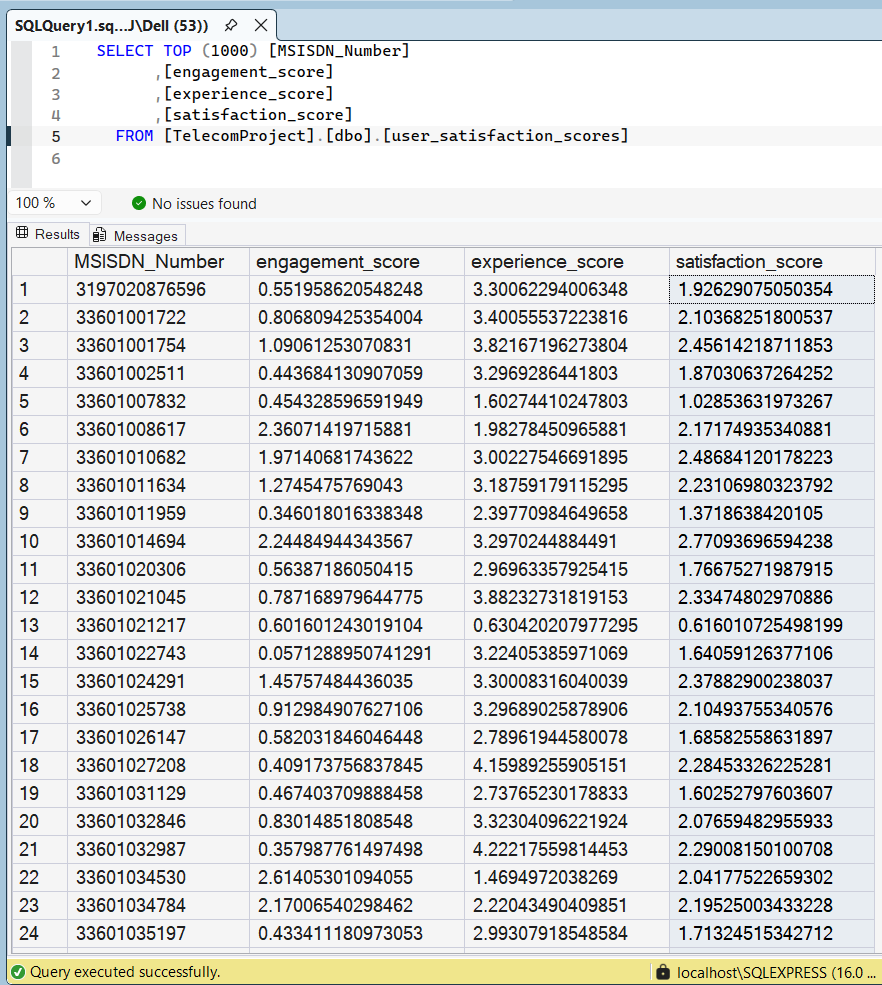

In [50]:
final_table = pd.read_csv('user_satisfaction_scores.csv')

In [52]:
final_table

,MSISDN/Number,engagement_score,experience_score,satisfaction_score
0,3197020876596,0.55,3.30,1.93
1,33601001722,0.81,3.40,2.10
2,33601001754,1.09,3.82,2.46
3,33601002511,0.44,3.30,1.87
4,33601007832,0.45,1.60,1.03
...,...,...,...,...
106851,33789967113,0.87,3.22,2.05
106852,33789980299,2.05,2.12,2.08
106853,33789996170,0.93,2.06,1.50
106854,33789997247,0.46,3.56,2.01
